In [ ]:
# SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kruskal, mannwhitneyu, spearmanr
import warnings
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [ ]:
# CARGAR DATOS
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = '/content/drive/MyDrive/Classroom/2º PHE CYBERSECURITY   APPLIED COMPUTING UNIT 16. COMPUTING RESEARCH PROJECT/PQC'
os.chdir(base_path)

# Cargar CSVs
df_collection = {}
for filename in os.listdir('.'):
    if filename.endswith('.csv'):
        df_name = filename.replace('.csv', '')
        df_collection[df_name] = pd.read_csv(filename)

print(f"{len(df_collection)} archivos cargados")
print(f"Total registros: {sum(len(df) for df in df_collection.values()):,}")

# Organizar por categoría
categorias = {
    'kyber': {
        'keygen': df_collection.get('kyber512_keygen'),
        'encaps': df_collection.get('kyber512_encaps'),
        'decaps': df_collection.get('kyber512_decaps')
    },
    'mldsa': {
        'keygen': df_collection.get('mldsa44_keygen'),
        'sign': df_collection.get('mldsa44_sign'),
        'verify': df_collection.get('mldsa44_verify')
    },
    'rsa': {
        'keygen': df_collection.get('rsa2048_keygen'),
        'encrypt': df_collection.get('rsa2048_encrypt'),
        'decrypt': df_collection.get('rsa2048_decrypt'),
        'sign': df_collection.get('rsa2048_sign'),
        'verify': df_collection.get('rsa2048_verify')
    },
    'ecdh': {
        'keygen': df_collection.get('ecdh256_keygen'),
        'derive': df_collection.get('ecdh256_derive')
    },
    'ecdsa': {
        'keygen': df_collection.get('ecdsa256_keygen'),
        'sign': df_collection.get('ecdsa256_sign'),
        'verify': df_collection.get('ecdsa256_verify')
    }
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
16 archivos cargados
Total registros: 16,000


In [ ]:
dataset_ejemplo = categorias['kyber']['keygen']

print("KYBER-512 KEYGEN - DATASET")
print()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(dataset_ejemplo)

# Restaurar configuración por defecto
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

KYBER-512 KEYGEN - DATASET



,iteration,timestamp,time_ms,memory_process_mb,memory_system_mb,temp_delta_c,temp_absolute_c,current_ma
0,1,2025-12-05T15:30:28.246712,0.063149,0.015625,0.000000,0.0,32.3,0.2
1,2,2025-12-05T15:30:28.252332,0.072223,0.000000,0.000000,0.0,31.8,0.0
2,3,2025-12-05T15:30:28.257843,0.069556,0.000000,0.000000,0.0,32.9,0.2
3,4,2025-12-05T15:30:28.263356,0.071093,0.000000,0.000000,0.0,32.3,-0.4
4,5,2025-12-05T15:30:28.268835,0.070111,0.000000,0.000000,0.0,32.9,-0.1
5,6,2025-12-05T15:30:28.274281,0.070796,0.000000,0.000000,0.0,32.9,-0.1
6,7,2025-12-05T15:30:28.279774,0.070593,0.015625,0.000000,0.0,34.0,0.1
7,8,2025-12-05T15:30:28.285297,0.070834,0.000000,0.000000,0.0,32.3,0.5
8,9,2025-12-05T15:30:28.290758,0.071444,0.000000,0.000000,0.0,32.3,-0.4
9,10,2025-12-05T15:30:28.296268,0.070685,0.000000,0.000000,0.0,32.3,0.0


In [ ]:
# ESTADÍSTICA DESCRIPTIVA

def calcular_estadisticas(df, nombre):
    time_data = df['time_ms']
    return {
        'Algoritmo': nombre,
        'n': len(time_data),
        'Media (ms)': time_data.mean(),
        'Mediana (ms)': time_data.median(),
        'Desv.Std (ms)': time_data.std(),
        'CV (%)': (time_data.std() / time_data.mean()) * 100,
        'Min (ms)': time_data.min(),
        'Max (ms)': time_data.max(),
        'P95 (ms)': time_data.quantile(0.95),
        'P99 (ms)': time_data.quantile(0.99)
    }

resultados = []
for alg, ops in categorias.items():
    for op, df in ops.items():
        if df is not None:
            nombre = f"{alg.upper()} {op.capitalize()}"
            resultados.append(calcular_estadisticas(df, nombre))

df_stats = pd.DataFrame(resultados).sort_values('Mediana (ms)')

print()
print("ESTADÍSTICA DESCRIPTIVA - LATENCIA (n=1,000)")
print()
display(df_stats.style.format({
    'Media (ms)': '{:.6f}',
    'Mediana (ms)': '{:.6f}',
    'Desv.Std (ms)': '{:.6f}',
    'CV (%)': '{:.2f}',
    'Min (ms)': '{:.6f}',
    'Max (ms)': '{:.6f}',
    'P95 (ms)': '{:.6f}',
    'P99 (ms)': '{:.6f}'
}).background_gradient(subset=['Mediana (ms)'], cmap='RdYlGn_r'))



ESTADÍSTICA DESCRIPTIVA - LATENCIA (n=1,000)



,Algoritmo,n,Media (ms),Mediana (ms),Desv.Std (ms),CV (%),Min (ms),Max (ms),P95 (ms),P99 (ms)
2,KYBER Decaps,1000,0.071395,0.070000,0.006654,9.32,0.064963,0.151482,0.077853,0.084997
0,KYBER Keygen,1000,0.082123,0.084686,0.009681,11.79,0.063149,0.169723,0.094372,0.110022
1,KYBER Encaps,1000,0.098373,0.096556,0.007247,7.37,0.083315,0.183242,0.107243,0.126488
13,ECDSA Keygen,1000,0.119124,0.117251,0.006621,5.56,0.109612,0.201242,0.129410,0.141417
11,ECDH Keygen,1000,0.119655,0.117871,0.006753,5.64,0.108352,0.186982,0.130245,0.138594
14,ECDSA Sign,1000,0.188119,0.185241,0.008558,4.55,0.173612,0.256205,0.204538,0.210817
3,MLDSA Keygen,1000,0.212970,0.208779,0.011481,5.39,0.195057,0.289335,0.235095,0.244168
5,MLDSA Verify,1000,0.215709,0.210983,0.011995,5.56,0.205927,0.303224,0.238950,0.265560
7,RSA Encrypt,1000,0.208220,0.223677,0.029948,14.38,0.157371,0.326131,0.250817,0.258588
10,RSA Verify,1000,0.228985,0.230159,0.020910,9.13,0.161242,0.326557,0.257021,0.269638


In [ ]:

# Extraer nombre base del algoritmo
df_stats['Algoritmo_Base'] = df_stats['Algoritmo'].apply(lambda x: x.split()[0])

# Ordenar por algoritmo y luego por mediana
df_stats_sorted = df_stats.sort_values(['Algoritmo_Base', 'Mediana (ms)']).reset_index(drop=True)

# Crear Styler con gradiente y ocultar índice correctamente
styler = df_stats_sorted.style \
    .format({
        'Media (ms)': '{:.6f}',
        'Mediana (ms)': '{:.6f}',
        'Desv.Std (ms)': '{:.6f}',
        'CV (%)': '{:.2f}',
        'Min (ms)': '{:.6f}',
        'Max (ms)': '{:.6f}',
        'P95 (ms)': '{:.6f}',
        'P99 (ms)': '{:.6f}'
    }) \
    .background_gradient(subset=['Mediana (ms)'], cmap='RdYlGn_r') \
    .hide(axis="index")  # Oculta el índice de la tabla

display(styler)


Algoritmo,n,Media (ms),Mediana (ms),Desv.Std (ms),CV (%),Min (ms),Max (ms),P95 (ms),P99 (ms),Algoritmo_Base
ECDH Keygen,1000,0.119655,0.117871,0.006753,5.64,0.108352,0.186982,0.130245,0.138594,ECDH
ECDH Derive,1000,0.249934,0.245094,0.012224,4.89,0.231205,0.337910,0.275911,0.283605,ECDH
ECDSA Keygen,1000,0.119124,0.117251,0.006621,5.56,0.109612,0.201242,0.129410,0.141417,ECDSA
ECDSA Sign,1000,0.188119,0.185241,0.008558,4.55,0.173612,0.256205,0.204538,0.210817,ECDSA
ECDSA Verify,1000,0.359765,0.353872,0.017659,4.91,0.333705,0.459206,0.396819,0.419606,ECDSA
KYBER Decaps,1000,0.071395,0.070000,0.006654,9.32,0.064963,0.151482,0.077853,0.084997,KYBER
KYBER Keygen,1000,0.082123,0.084686,0.009681,11.79,0.063149,0.169723,0.094372,0.110022,KYBER
KYBER Encaps,1000,0.098373,0.096556,0.007247,7.37,0.083315,0.183242,0.107243,0.126488,KYBER
MLDSA Keygen,1000,0.212970,0.208779,0.011481,5.39,0.195057,0.289335,0.235095,0.244168,MLDSA
MLDSA Verify,1000,0.215709,0.210983,0.011995,5.56,0.205927,0.303224,0.238950,0.265560,MLDSA


In [ ]:

fig = px.scatter(
    df_stats_sorted,
    x='Mediana (ms)',
    y='Algoritmo',
    color='Mediana (ms)',
    color_continuous_scale='RdYlGn_r',
    hover_data=['CV (%)'],
    orientation='h'
)

# Para que la operación más rápida quede arriba
fig.update_yaxes(autorange="reversed")

# Escala logarítmica si quieres resaltar diferencias pequeñas
fig.update_xaxes(type='log')

fig.show()


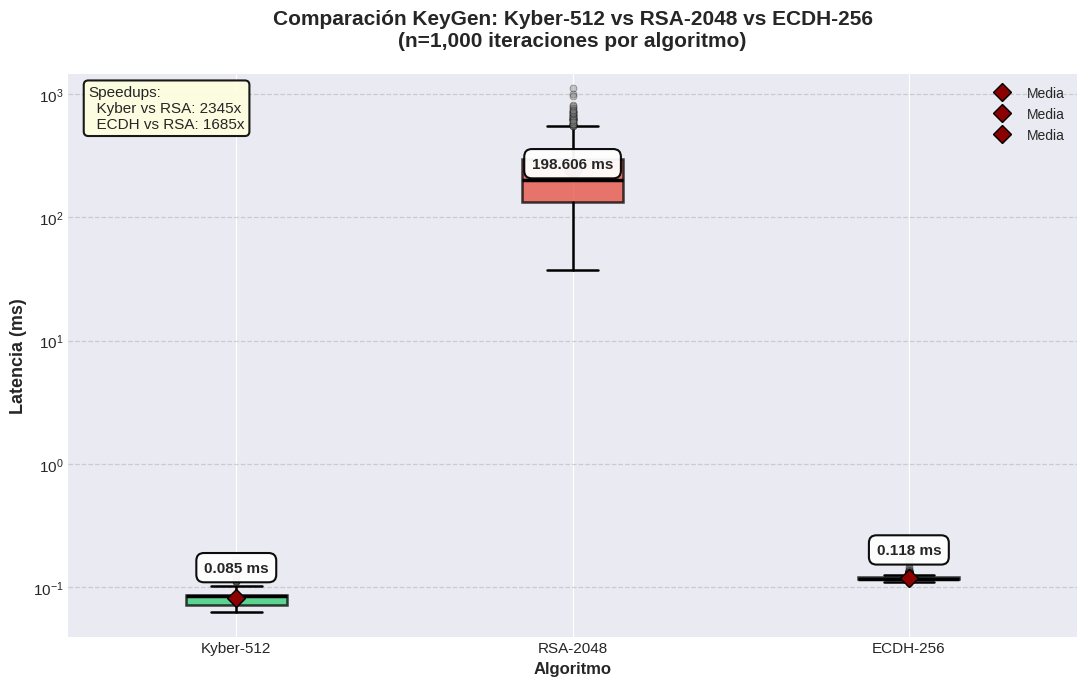


  Medianas: Kyber=0.085 ms, RSA=198.606 ms, ECDH=0.118 ms
  Speedup Kyber vs RSA: 2345x


In [ ]:
# BOX PLOT: KEYGEN COMPARISON

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(11, 7))

# Preparar datos
keygen_data = [
    categorias['kyber']['keygen']['time_ms'].values,
    categorias['rsa']['keygen']['time_ms'].values,
    categorias['ecdh']['keygen']['time_ms'].values
]
labels = ['Kyber-512', 'RSA-2048', 'ECDH-256']
colors = ['#2ecc71', '#e74c3c', '#3498db']

# Crear box plot
bp = ax.boxplot(
    keygen_data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='darkred', markersize=9,
                   markeredgecolor='black', markeredgewidth=1, label='Media'),
    medianprops=dict(linewidth=2.5, color='black'),
    whiskerprops=dict(linewidth=1.8, color='black'),
    capprops=dict(linewidth=1.8, color='black'),
    boxprops=dict(linewidth=1.8),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5,
                    alpha=0.4, markeredgecolor='black', markeredgewidth=0.5)
)

# Colorear cajas
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Escala logarítmica
ax.set_yscale('log')

# Títulos y etiquetas
ax.set_ylabel('Latencia (ms)', fontsize=13, fontweight='bold')
ax.set_title('Comparación KeyGen: Kyber-512 vs RSA-2048 vs ECDH-256\n(n=1,000 iteraciones por algoritmo)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')

# Grid
ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.9, color='gray')
ax.set_axisbelow(True)

# Añadir medianas como anotaciones
medianas = [np.median(data) for data in keygen_data]
for i, (median, label) in enumerate(zip(medianas, labels), 1):
    y_offset = median * 1.2 if median > 1 else median * 1.5
    ax.text(i, y_offset, f'{median:.3f} ms',
            ha='center', va='bottom', fontweight='bold',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                     edgecolor='black', linewidth=1.5, alpha=0.95))

# Speedups como anotaciones
speedup_kr = medianas[1] / medianas[0]  # RSA vs Kyber
speedup_er = medianas[1] / medianas[2]  # RSA vs ECDH
ax.text(0.02, 0.98, f'Speedups:\n  Kyber vs RSA: {speedup_kr:.0f}x\n  ECDH vs RSA: {speedup_er:.0f}x',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9,
                 edgecolor='black', linewidth=1.5))

# Leyenda
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')

# Ajustar límites
ax.set_ylim(bottom=0.04, top=max(medianas[1], max(keygen_data[1])) * 1.3)

plt.tight_layout()
plt.show()

print()
print(f"  Medianas: Kyber={medianas[0]:.3f} ms, RSA={medianas[1]:.3f} ms, ECDH={medianas[2]:.3f} ms")
print(f"  Speedup Kyber vs RSA: {speedup_kr:.0f}x")

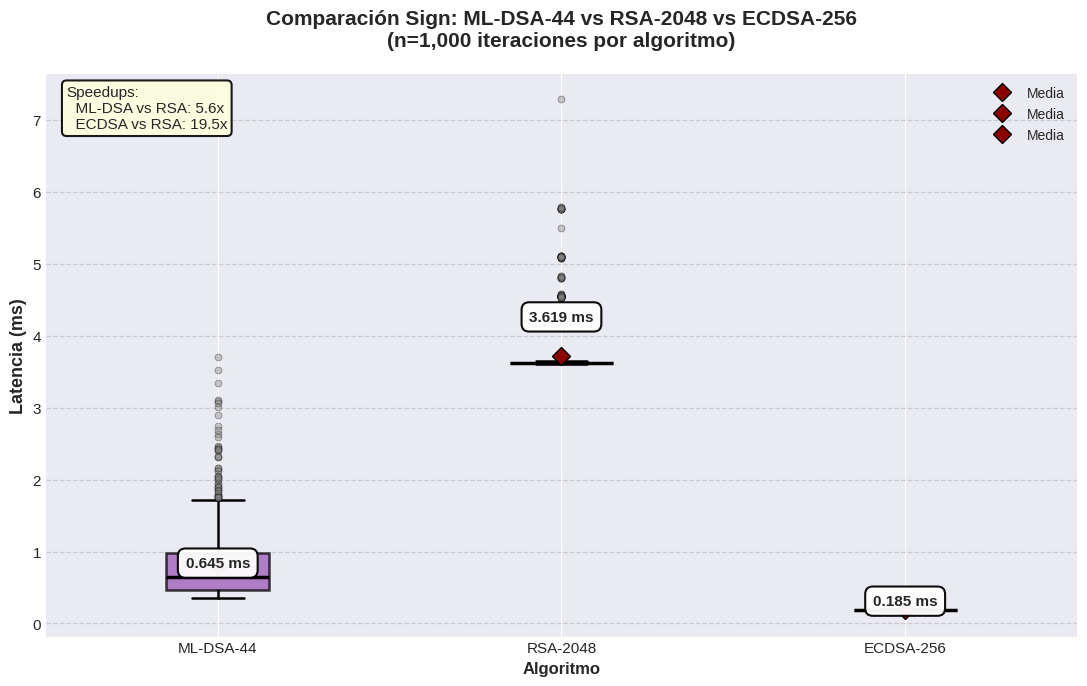


  Medianas: ML-DSA=0.645 ms, RSA=3.619 ms, ECDSA=0.185 ms
  Speedup ML-DSA vs RSA: 5.6x


In [ ]:
# BOX PLOT: SIGN COMPARISON

fig, ax = plt.subplots(figsize=(11, 7))

# Preparar datos
sign_data = [
    categorias['mldsa']['sign']['time_ms'].values,
    categorias['rsa']['sign']['time_ms'].values,
    categorias['ecdsa']['sign']['time_ms'].values
]
labels = ['ML-DSA-44', 'RSA-2048', 'ECDSA-256']
colors = ['#9b59b6', '#e74c3c', '#f39c12']

# Crear box plot
bp = ax.boxplot(
    sign_data,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='darkred', markersize=9,
                   markeredgecolor='black', markeredgewidth=1, label='Media'),
    medianprops=dict(linewidth=2.5, color='black'),
    whiskerprops=dict(linewidth=1.8, color='black'),
    capprops=dict(linewidth=1.8, color='black'),
    boxprops=dict(linewidth=1.8),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=5,
                    alpha=0.4, markeredgecolor='black', markeredgewidth=0.5)
)

# Colorear cajas
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Títulos y etiquetas
ax.set_ylabel('Latencia (ms)', fontsize=13, fontweight='bold')
ax.set_title('Comparación Sign: ML-DSA-44 vs RSA-2048 vs ECDSA-256\n(n=1,000 iteraciones por algoritmo)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')

# Grid
ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.9, color='gray')
ax.set_axisbelow(True)

# Añadir medianas
medianas = [np.median(data) for data in sign_data]
for i, (median, label) in enumerate(zip(medianas, labels), 1):
    y_offset = median * 1.15
    ax.text(i, y_offset, f'{median:.3f} ms',
            ha='center', va='bottom', fontweight='bold',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                     edgecolor='black', linewidth=1.5, alpha=0.95))

# Speedups
speedup_mr = medianas[1] / medianas[0]  # RSA vs ML-DSA
speedup_er = medianas[1] / medianas[2]  # RSA vs ECDSA
ax.text(0.02, 0.98, f'Speedups:\n  ML-DSA vs RSA: {speedup_mr:.1f}x\n  ECDSA vs RSA: {speedup_er:.1f}x',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9,
                 edgecolor='black', linewidth=1.5))

# Leyenda
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.show()

print()
print(f"  Medianas: ML-DSA={medianas[0]:.3f} ms, RSA={medianas[1]:.3f} ms, ECDSA={medianas[2]:.3f} ms")
print(f"  Speedup ML-DSA vs RSA: {speedup_mr:.1f}x")

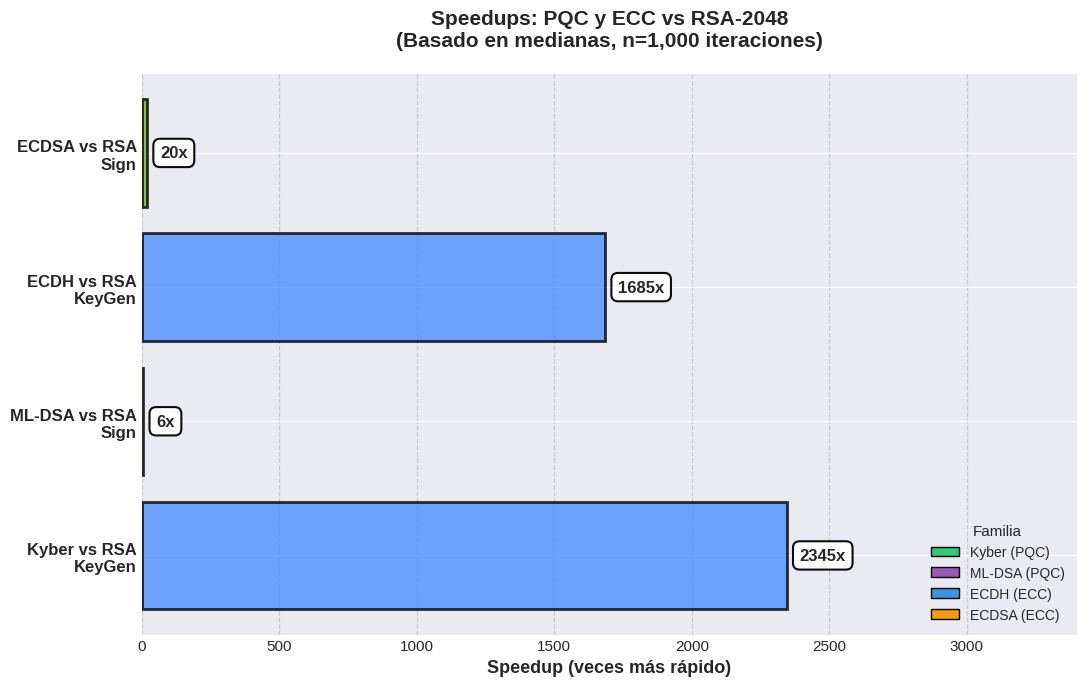


  Kyber vs RSA KeyGen: 2345x
  ML-DSA vs RSA Sign: 6x
  ECDH vs RSA KeyGen: 1685x
  ECDSA vs RSA Sign: 20x


In [ ]:
# SPEEDUPS BAR CHART
fig, ax = plt.subplots(figsize=(11, 7))

# Calcular speedups
kyber_median = categorias['kyber']['keygen']['time_ms'].median()
rsa_keygen_median = categorias['rsa']['keygen']['time_ms'].median()
ecdh_median = categorias['ecdh']['keygen']['time_ms'].median()
mldsa_median = categorias['mldsa']['sign']['time_ms'].median()
rsa_sign_median = categorias['rsa']['sign']['time_ms'].median()
ecdsa_median = categorias['ecdsa']['sign']['time_ms'].median()

speedups = {
    'Kyber vs RSA\nKeyGen': rsa_keygen_median / kyber_median,
    'ML-DSA vs RSA\nSign': rsa_sign_median / mldsa_median,
    'ECDH vs RSA\nKeyGen': rsa_keygen_median / ecdh_median,
    'ECDSA vs RSA\nSign': rsa_sign_median / ecdsa_median
}

# Colores por familia
colors_speedup = ['#4d8fff', '#75a928', '#4d8fff', '#75a928']

# Crear barras horizontales
y_pos = np.arange(len(speedups))
bars = ax.barh(y_pos, list(speedups.values()),
               color=colors_speedup, alpha=0.8,
               edgecolor='black', linewidth=2)

# Etiquetas
ax.set_yticks(y_pos)
ax.set_yticklabels(list(speedups.keys()), fontsize=12, fontweight='bold')
ax.set_xlabel('Speedup (veces más rápido)', fontsize=13, fontweight='bold')
ax.set_title('Speedups: PQC y ECC vs RSA-2048\n(Basado en medianas, n=1,000 iteraciones)',
             fontsize=15, fontweight='bold', pad=20)

# Grid
ax.xaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.9, color='gray')
ax.set_axisbelow(True)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, speedups.values())):
    ax.text(value + max(speedups.values())*0.02, i, f'{value:.0f}x',
            va='center', ha='left', fontweight='bold', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor='black', linewidth=1.5, alpha=0.95))

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Kyber (PQC)'),
    Patch(facecolor='#9b59b6', edgecolor='black', label='ML-DSA (PQC)'),
    Patch(facecolor='#3498db', edgecolor='black', label='ECDH (ECC)'),
    Patch(facecolor='#f39c12', edgecolor='black', label='ECDSA (ECC)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.95, edgecolor='black', title='Familia')

ax.set_xlim(0, max(speedups.values()) * 1.45)

plt.tight_layout()
plt.show()

print()
for comp, speed in speedups.items():
    print(f"  {comp.replace(chr(10), ' ')}: {speed:.0f}x")

In [ ]:
# ANÁLISIS TÉRMICO AGREGADO

resultados_termicos = []
for alg, ops in categorias.items():
    for op, df in ops.items():
        if df is not None:
            resultados_termicos.append({
                'Algoritmo': f"{alg.upper()} {op.capitalize()}",
                'Latencia Mediana (ms)': df['time_ms'].median(),
                'Temp Δ Promedio (°C)': df['temp_delta_c'].mean(),
                'Temp Acumulado (°C)': df['temp_delta_c'].sum()
            })

df_termico = pd.DataFrame(resultados_termicos).sort_values('Temp Acumulado (°C)', ascending=False)


print("ANÁLISIS TÉRMICO AGREGADO (1,000 iteraciones)")
print()
display(df_termico.style.format({
    'Latencia Mediana (ms)': '{:.6f}',
    'Temp Δ Promedio (°C)': '{:.3f}',
    'Temp Acumulado (°C)': '{:.2f}'
}).background_gradient(subset=['Temp Acumulado (°C)'], cmap='YlOrRd'))


print("\nMÁS CALIENTES:")
for _, row in df_termico.head(3).iterrows():
    print(f"  {row['Algoritmo']}: {row['Temp Acumulado (°C)']:+.2f}°C")

print("\nMÁS FRÍOS:")
for _, row in df_termico.tail(3).iterrows():
    print(f"  {row['Algoritmo']}: {row['Temp Acumulado (°C)']:+.2f}°C")

ANÁLISIS TÉRMICO AGREGADO (1,000 iteraciones)



,Algoritmo,Latencia Mediana (ms),Temp Δ Promedio (°C),Temp Acumulado (°C)
2,KYBER Decaps,0.070000,0.020,20.30
6,RSA Keygen,198.606352,0.015,15.00
10,RSA Verify,0.230159,0.013,12.80
13,ECDSA Keygen,0.117251,0.007,7.00
15,ECDSA Verify,0.353872,0.007,6.80
4,MLDSA Sign,0.644958,0.006,6.10
8,RSA Decrypt,3.603845,0.006,6.00
5,MLDSA Verify,0.210983,0.002,2.10
7,RSA Encrypt,0.223677,0.002,2.00
14,ECDSA Sign,0.185241,-0.003,-3.00



MÁS CALIENTES:
  KYBER Decaps: +20.30°C
  RSA Keygen: +15.00°C
  RSA Verify: +12.80°C

MÁS FRÍOS:
  RSA Sign: -7.30°C
  ECDH Derive: -12.80°C
  MLDSA Keygen: -14.50°C


In [ ]:

# ANÁLISIS TÉRMICO AGREGADO

# Preparar datos
resultados_termicos = []
for alg, ops in categorias.items():
    for op, df in ops.items():
        if df is not None:
            resultados_termicos.append({
                'Operación': f"{alg.upper()} {op.capitalize()}",
                'Latencia Mediana (ms)': df['time_ms'].median(),
                'Temp Δ Promedio (°C)': df['temp_delta_c'].mean(),
                'Temp Acumulado (°C)': df['temp_delta_c'].sum()
            })

df_termico = pd.DataFrame(resultados_termicos).sort_values(
    'Temp Acumulado (°C)',
    ascending=True
)

# Función para asignar colores según temperatura
def asignar_color(temp):
    if temp > 15:
        return '#dc2626'
    elif temp > 10:
        return '#f87171'
    elif temp > 5:
        return '#fbbf24'
    elif temp > 0:
        return '#fef3c7'
    elif temp > -5:
        return '#bfdbfe'
    elif temp > -10:
        return '#60a5fa'
    else:
        return '#2563eb'

colores = [asignar_color(temp) for temp in df_termico['Temp Acumulado (°C)']]

# Crear figura
fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_termico['Operación'],
    x=df_termico['Temp Acumulado (°C)'],
    orientation='h',
    marker=dict(
        color=colores,
        line=dict(color='rgba(0,0,0,0.3)', width=1)
    ),
    text=[f'{t:+.1f}°C' for t in df_termico['Temp Acumulado (°C)']],
    textposition='outside',
    textfont=dict(size=14, color='black', family='Arial Black'),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Δ Temp Acumulado: <b>%{x:+.2f}°C</b><br>'
        'Latencia Mediana: %{customdata[0]:.3f} ms<br>'
        'Δ Temp Promedio: %{customdata[1]:+.3f}°C<br>'
        '<extra></extra>'
    ),
    customdata=df_termico[['Latencia Mediana (ms)', 'Temp Δ Promedio (°C)']].values
))

# Línea de referencia en 0°C (neutro térmico)
fig.add_vline(
    x=0,
    line_dash="solid",
    line_color="black",
    line_width=3,
    annotation_text="Neutro (0°C)",
    annotation_position="top",
    annotation_font_size=14,
    annotation_font_color="black"
)

# Áreas sombreadas (zonas térmicas)
fig.add_vrect(
    x0=-20, x1=0,
    fillcolor="blue",
    opacity=0.08,
    layer="below",
    line_width=0,
)

fig.add_vrect(
    x0=0, x1=25,
    fillcolor="red",
    opacity=0.08,
    layer="below",
    line_width=0,
)

# Layout
fig.update_layout(
    title={
        'text': (
            'Impacto Térmico Acumulado: Operaciones Criptográficas<br>'
            '<sub>Δ°C tras 1,000 iteraciones en Raspberry Pi 5 (ARM Cortex-A76)</sub>'
        ),
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'family': 'Arial', 'color': '#1f2937'}
    },
    xaxis_title='Δ Temperatura Acumulado (°C)',
    xaxis=dict(
        zeroline=True,
        zerolinewidth=3,
        zerolinecolor='black',
        gridcolor='#e5e7eb',
        showgrid=True,
        range=[-20, 25],
        tickfont=dict(size=13)
    ),
    yaxis_title='',
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=13)
    ),
    height=800,
    width=1400,
    font=dict(size=13, family='Arial'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=200, r=150, t=120, b=80),
    hovermode='y unified'
)

# Añadir anotación explicativa
fig.add_annotation(
    text=(
        '<b>Insight Clave:</b><br>'
        'Impacto térmico ≠ Latencia individual<br>'
        'Densidad temporal > Latencia absoluta'
    ),
    xref="paper", yref="paper",
    x=0.98, y=0.02,
    showarrow=False,
    font=dict(size=12, color='#374151'),
    align='left',
    bgcolor='rgba(249, 250, 251, 0.9)',
    bordercolor='#9ca3af',
    borderwidth=2,
    borderpad=10
)

fig.show()


In [ ]:
# SCATTER INTERACTIVO - LATENCIA VS TEMPERATURA

# Preparar datos
df_scatter = df_termico.copy()
df_scatter['Familia'] = df_scatter['Operación'].apply(lambda x:
    'Kyber' if 'KYBER' in x else
    'ML-DSA' if 'MLDSA' in x else
    'RSA' if 'RSA' in x else
    'ECC'
)

# Colores por familia
color_map = {
    'Kyber': '#2ecc71',
    'ML-DSA': '#9b59b6',
    'RSA': '#e74c3c',
    'ECC': '#3498db'
}

fig = px.scatter(
    df_scatter,
    x='Latencia Mediana (ms)',
    y='Temp Acumulado (°C)',
    size='Latencia Mediana (ms)',
    color='Familia',
    color_discrete_map=color_map,
    hover_data={
        'Operación': True,
        'Latencia Mediana (ms)': ':.6f',
        'Temp Acumulado (°C)': ':.2f',
        'Familia': False
    },
    text='Operación',
    log_x=False,
    title='Relación Latencia vs Impacto Térmico Acumulado<br><sub>(1,000 iteraciones, tamaño de burbuja ∝ latencia)</sub>'
)

# Personalizar
fig.update_traces(
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        line=dict(width=1.5, color='black'),
        opacity=0.7
    )
)

fig.update_layout(
    xaxis_title='Latencia Mediana (ms)',
    yaxis_title='Impacto Térmico Acumulado (°C)',
    font=dict(size=12),
    plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgray', showline=True, linewidth=1, linecolor='black'),
    yaxis=dict(gridcolor='lightgray', showline=True, linewidth=1, linecolor='black',
               zeroline=True, zerolinewidth=2, zerolinecolor='gray'),
    width=1200,
    height=700,
    title_x=0.5,
    title_font=dict(size=16, color='black', family='Arial Black'),
    legend=dict(title='Familia de Algoritmo', font=dict(size=11))
)

# ANOTACIÓN 1: ML-DSA Sign (CORRECTA)
fig.add_annotation(
    x=df_scatter[df_scatter['Operación'].str.contains('MLDSA Sign')]['Latencia Mediana (ms)'].values[0],
    y=df_scatter[df_scatter['Operación'].str.contains('MLDSA Sign')]['Temp Acumulado (°C)'].values[0],
    text="ML-DSA Sign:<br>Rápido pero intensivo<br>(requiere ventilación)",
    showarrow=True,
    arrowhead=2,
    arrowcolor='red',
    ax=50,
    ay=-50,
    bgcolor='yellow',
    opacity=0.8,
    font=dict(size=10, color='black')
)

# ANOTACIÓN 2: RSA KeyGen (CORREGIDA)
fig.add_annotation(
    x=df_scatter[df_scatter['Operación'].str.contains('RSA Keygen')]['Latencia Mediana (ms)'].values[0],
    y=df_scatter[df_scatter['Operación'].str.contains('RSA Keygen')]['Temp Acumulado (°C)'].values[0],
    text="RSA KeyGen:<br>Lento Y caliente<br>(evitar en IoT)",
    showarrow=True,
    arrowhead=2,
    arrowcolor='red',
    ax=-80,
    ay=-30,
    bgcolor='lightcoral',
    opacity=0.8,
    font=dict(size=10, color='black')
)

# ANOTACIÓN 3: Kyber KeyGen (CORRECTA)
fig.add_annotation(
    x=df_scatter[df_scatter['Operación'].str.contains('KYBER Keygen')]['Latencia Mediana (ms)'].values[0],
    y=df_scatter[df_scatter['Operación'].str.contains('KYBER Keygen')]['Temp Acumulado (°C)'].values[0],
    text="Kyber KeyGen:<br>Rápido Y frío<br>(ideal IoT)",
    showarrow=True,
    arrowhead=2,
    arrowcolor='green',
    ax=30,
    ay=50,
    bgcolor='lightgreen',
    opacity=0.8,
    font=dict(size=10, color='black')
)

fig.show()

In [ ]:
#  TEST DE NORMALIDAD


print("TEST DE NORMALIDAD - SHAPIRO-WILK (α=0.05)")
print()

resultados_normalidad = []
for alg, ops in categorias.items():
    for op, df in ops.items():
        if df is not None:
            nombre = f"{alg.upper()} {op.capitalize()}"
            stat, p = shapiro(df['time_ms'])
            resultados_normalidad.append({
                'Algoritmo': nombre,
                'W': stat,
                'p-value': p,
                'Normal': 'SÍ' if p > 0.05 else 'NO'
            })

df_normalidad = pd.DataFrame(resultados_normalidad)
display(df_normalidad)


n_normales = (df_normalidad['Normal'] == 'SÍ').sum()
print(f"\nNormales: {n_normales}/{len(df_normalidad)}")

TEST DE NORMALIDAD - SHAPIRO-WILK (α=0.05)



,Algoritmo,W,p-value,Normal
0,KYBER Keygen,0.811741,1.373038e-32,NO
1,KYBER Encaps,0.540484,4.474002e-45,NO
2,KYBER Decaps,0.372638,6.272464e-50,NO
3,MLDSA Keygen,0.768581,2.733611e-35,NO
4,MLDSA Sign,0.799816,2.217079e-33,NO
5,MLDSA Verify,0.615649,2.084236e-42,NO
6,RSA Keygen,0.875318,1.558018e-27,NO
7,RSA Encrypt,0.821416,6.456032e-32,NO
8,RSA Decrypt,0.289807,6.205370e-52,NO
9,RSA Sign,0.296305,8.765084e-52,NO



Normales: 0/16


In [ ]:
# ============ VISUALIZACIÓN 4: Q-Q PLOTS MÚLTIPLES ============

import plotly.subplots as sp
import plotly.graph_objects as go
import scipy.stats as stats

# Seleccionar 4 casos representativos (MINÚSCULAS)
casos_ejemplo = [
    ('kyber', 'keygen'),   # Ejemplo más normal
    ('rsa', 'keygen'),     # Ejemplo menos normal
    ('mldsa', 'sign'),     # Variabilidad alta
    ('ecdsa', 'sign')      # Variabilidad baja
]

fig = sp.make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{alg.upper()} {op.capitalize()}" for alg, op in casos_ejemplo]
)

for idx, (alg, op) in enumerate(casos_ejemplo, 1):
    df_op = categorias[alg][op]  # ← Ahora funciona
    data_sorted = np.sort(df_op['time_ms'])
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(data_sorted)))

    row = (idx - 1) // 2 + 1
    col = (idx - 1) % 2 + 1

    # Scatter de Q-Q
    fig.add_trace(
        go.Scatter(
            x=theoretical_quantiles,
            y=data_sorted,
            mode='markers',
            marker=dict(size=4, color='blue', opacity=0.6),
            name=f'{alg.upper()} {op}'
        ),
        row=row, col=col
    )

    # Línea de referencia (distribución perfecta)
    fig.add_trace(
        go.Scatter(
            x=theoretical_quantiles,
            y=theoretical_quantiles * data_sorted.std() + data_sorted.mean(),
            mode='lines',
            line=dict(color='red', dash='dash'),
            name='Normal teórica',
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text='Q-Q Plots: Diagnóstico de Normalidad',
    height=700,
    showlegend=False
)

fig.update_xaxes(title_text='Cuantiles Teóricos')
fig.update_yaxes(title_text='Cuantiles Observados (ms)')

fig.show()

In [ ]:
# ============ VERSIÓN MEJORADA CON ANOTACIONES ============
import plotly.subplots as sp
import scipy.stats as stats

casos_ejemplo = [
    ('kyber', 'keygen'),   # Más normal
    ('rsa', 'keygen'),     # Menos normal
    ('mldsa', 'sign'),     # Variabilidad alta
    ('ecdsa', 'sign')      # Baja variabilidad
]

fig = sp.make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{alg.upper()} {op.capitalize()}<br><sub>W={shapiro(categorias[alg][op]['time_ms'])[0]:.4f}</sub>"
                    for alg, op in casos_ejemplo]
)

for idx, (alg, op) in enumerate(casos_ejemplo, 1):
    df_op = categorias[alg][op]
    data_sorted = np.sort(df_op['time_ms'])
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(data_sorted)))

    row = (idx - 1) // 2 + 1
    col = (idx - 1) % 2 + 1

    # Scatter de Q-Q
    fig.add_trace(
        go.Scatter(
            x=theoretical_quantiles,
            y=data_sorted,
            mode='markers',
            marker=dict(size=5, color='#1f77b4', opacity=0.6),
            name=f'{alg.upper()} {op}',
            hovertemplate='Teórico: %{x:.2f}<br>Observado: %{y:.3f} ms<extra></extra>'
        ),
        row=row, col=col
    )

    # Línea de referencia (distribución perfecta)
    fig.add_trace(
        go.Scatter(
            x=theoretical_quantiles,
            y=theoretical_quantiles * data_sorted.std() + data_sorted.mean(),
            mode='lines',
            line=dict(color='red', dash='dash', width=2),
            name='Normal teórica',
            showlegend=False,
            hoverinfo='skip'
        ),
        row=row, col=col
    )

    # AÑADIR ANOTACIÓN DE INTERPRETACIÓN
    if alg == 'kyber' and op == 'keygen':
        interpretacion = "Más cercano a normal"
        color = '#5cb85c'  # Verde
    elif alg == 'rsa' and op == 'keygen':
        interpretacion = "Desviaciones pronunciadas"
        color = '#f0ad4e'  # Naranja
    elif alg == 'mldsa' and op == 'sign':
        interpretacion = "Cola superior extensa"
        color = '#d9534f'  # Rojo
    else:
        interpretacion = "Outliers marcados"
        color = '#d9534f'  # Rojo

    fig.add_annotation(
        text=f"<i>{interpretacion}</i>",
        xref=f"x{idx}", yref=f"y{idx}",
        x=0, y=data_sorted.max() * 0.95,
        showarrow=False,
        font=dict(size=10, color=color),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor=color,
        borderwidth=1,
        row=row, col=col
    )

fig.update_layout(
    title={
        'text': 'Q-Q Plots: Diagnóstico de Normalidad',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    height=750,
    showlegend=False,
    font=dict(size=11)
)

fig.update_xaxes(title_text='Cuantiles Teóricos', title_font=dict(size=11))
fig.update_yaxes(title_text='Cuantiles Observados (ms)', title_font=dict(size=11))

fig.show()



In [ ]:
# ESTADÍSTICA INFERENCIAL


print("ESTADÍSTICA INFERENCIAL - TESTS NO PARAMÉTRICOS")
print()

resultados_keygen = []
resultados_sign = []

# 1. KEY EXCHANGE - KeyGen
print("\n1. KEY EXCHANGE - KeyGen (Kyber vs RSA vs ECDH)")
print("-"*80)

kyber_keygen = categorias['kyber']['keygen']['time_ms']
rsa_keygen = categorias['rsa']['keygen']['time_ms']
ecdh_keygen = categorias['ecdh']['keygen']['time_ms']

# KRUSKAL-WALLIS
h_stat, p_kruskal = kruskal(kyber_keygen, rsa_keygen, ecdh_keygen)
print(f"\nKruskal-Wallis:")
print(f"  H-statistic: {h_stat:.2f}")
print(f"  p-value: {p_kruskal:.2e}")
print(f"  {'✓ Diferencias significativas (p<0.05)' if p_kruskal < 0.05 else '✗ Sin diferencias'}")

# MANN-WHITNEY U pareados
comparaciones_keygen_list = [
    ('Kyber', kyber_keygen, 'RSA', rsa_keygen),
    ('Kyber', kyber_keygen, 'ECDH', ecdh_keygen),
    ('ECDH', ecdh_keygen, 'RSA', rsa_keygen)
]

print(f"\nMann-Whitney U (pareados):")
for nombre1, data1, nombre2, data2 in comparaciones_keygen_list:
    u, p = mannwhitneyu(data1, data2, alternative='two-sided')
    speedup = data2.median() / data1.median()
    resultados_keygen.append({
        'Comparación': f"{nombre1} vs {nombre2}",
        'U': u,
        'p-value': p,
        'Speedup': speedup
    })
    print(f"\n  {nombre1} vs {nombre2}:")
    print(f"    U = {u:.1f}, p = {p:.2e}")
    print(f"    Speedup: {speedup:.1f}x")
    print(f"    {'✓ Significativo' if p < 0.05 else '✗ No significativo'}")


# 2. DIGITAL SIGNATURES - Sign
print("\n")
print("2. DIGITAL SIGNATURES - Sign (ML-DSA vs RSA vs ECDSA)")
print("-"*80)

mldsa_sign = categorias['mldsa']['sign']['time_ms']
rsa_sign = categorias['rsa']['sign']['time_ms']
ecdsa_sign = categorias['ecdsa']['sign']['time_ms']

# KRUSKAL-WALLIS
h_stat, p_kruskal = kruskal(mldsa_sign, rsa_sign, ecdsa_sign)
print(f"\nKruskal-Wallis:")
print(f"  H-statistic: {h_stat:.2f}")
print(f"  p-value: {p_kruskal:.2e}")
print(f"  {'✓ Diferencias significativas (p<0.05)' if p_kruskal < 0.05 else '✗ Sin diferencias'}")

# MANN-WHITNEY U pareados
comparaciones_sign_list = [
    ('ML-DSA', mldsa_sign, 'RSA', rsa_sign),
    ('ML-DSA', mldsa_sign, 'ECDSA', ecdsa_sign),
    ('ECDSA', ecdsa_sign, 'RSA', rsa_sign)
]

print(f"\nMann-Whitney U (pareados):")
for nombre1, data1, nombre2, data2 in comparaciones_sign_list:
    u, p = mannwhitneyu(data1, data2, alternative='two-sided')
    speedup = data2.median() / data1.median()
    resultados_sign.append({
        'Comparación': f"{nombre1} vs {nombre2}",
        'U': u,
        'p-value': p,
        'Speedup': speedup
    })
    print(f"\n  {nombre1} vs {nombre2}:")
    print(f"    U = {u:.1f}, p = {p:.2e}")
    print(f"    Speedup: {speedup:.1f}x")
    print(f"    {'✓ Significativo' if p < 0.05 else '✗ No significativo'}")



ESTADÍSTICA INFERENCIAL - TESTS NO PARAMÉTRICOS


1. KEY EXCHANGE - KeyGen (Kyber vs RSA vs ECDH)
--------------------------------------------------------------------------------

Kruskal-Wallis:
  H-statistic: 2651.34
  p-value: 0.00e+00
  ✓ Diferencias significativas (p<0.05)

Mann-Whitney U (pareados):

  Kyber vs RSA:
    U = 0.0, p = 0.00e+00
    Speedup: 2345.2x
    ✓ Significativo

  Kyber vs ECDH:
    U = 5445.5, p = 0.00e+00
    Speedup: 1.4x
    ✓ Significativo

  ECDH vs RSA:
    U = 0.0, p = 0.00e+00
    Speedup: 1684.9x
    ✓ Significativo


2. DIGITAL SIGNATURES - Sign (ML-DSA vs RSA vs ECDSA)
--------------------------------------------------------------------------------

Kruskal-Wallis:
  H-statistic: 2663.30
  p-value: 0.00e+00
  ✓ Diferencias significativas (p<0.05)

Mann-Whitney U (pareados):

  ML-DSA vs RSA:
    U = 930.0, p = 0.00e+00
    Speedup: 5.6x
    ✓ Significativo

  ML-DSA vs ECDSA:
    U = 1000000.0, p = 0.00e+00
    Speedup: 0.3x
    ✓ Significativo

 

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ============================================================================
# HEATMAP: P-VALUES Y SEPARACIÓN
# ============================================================================

# Crear matriz de comparaciones
algoritmos = ['Kyber', 'ECDH', 'RSA', 'ML-DSA', 'ECDSA']
matriz_u = np.zeros((5, 5))
matriz_p = np.ones((5, 5))

# Mapeo índices
idx_map = {'Kyber': 0, 'ECDH': 1, 'RSA': 2, 'ML-DSA': 3, 'ECDSA': 4}

# Llenar matriz con resultados
for result in resultados_keygen + resultados_sign:
    comp = result['Comparación'].split(' vs ')
    if len(comp) == 2 and comp[0] in idx_map and comp[1] in idx_map:
        i, j = idx_map[comp[0]], idx_map[comp[1]]
        matriz_u[i, j] = result['U']
        matriz_u[j, i] = result['U']  # Simétrica
        matriz_p[i, j] = result['p-value']
        matriz_p[j, i] = result['p-value']

# Crear heatmap
fig = go.Figure(data=go.Heatmap(
    z=-np.log10(matriz_p + 1e-10),  # -log10(p) para visualizar mejor
    x=algoritmos,
    y=algoritmos,
    colorscale='Reds',
    text=np.where(
        matriz_u == 0,
        'U=0<br>Perfecto',
        np.where(
            matriz_u > 0,
            [[f'U={u:.0f}<br>p<0.001' for u in fila] for fila in matriz_u],
            ''
        )
    ),
    texttemplate='%{text}',
    textfont={"size": 11, "color": "white"},
    colorbar=dict(
        title="-log₁₀(p)<br>(mayor = más<br>significativo)",
        titleside="right"
    ),
    hovertemplate='<b>%{y} vs %{x}</b><br>Significancia: %{z:.1f}<extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Heatmap Significancia Estadística<br><sub>Mann-Whitney U | Rojo intenso = Alta significancia</sub>',
        'x': 0.5,
        'font': {'size': 18}
    },
    xaxis_title='Algoritmo',
    yaxis_title='Algoritmo',
    height=700,
    width=800,
    font=dict(size=13)
)

fig.show()


In [ ]:
# CORRELACIÓN SPEARMAN

print("CORRELACIÓN DE SPEARMAN - RSA-2048 KeyGen")
print()

df_rsa_keygen = categorias['rsa']['keygen']
variables = ['time_ms', 'memory_system_mb', 'temp_delta_c', 'temp_absolute_c']
df_corr = df_rsa_keygen[variables].dropna()

# Matriz de correlación
corr_matrix = df_corr.corr(method='spearman')

print("\nMatriz de Correlación (ρ):")
display(corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format("{:.3f}"))

# Correlaciones específicas con p-values
print("\n")
print("CORRELACIONES ESPECÍFICAS:")
print()

correlaciones_clave = [
    ('time_ms', 'temp_delta_c', 'Latencia vs Incremento Temp'),
    ('time_ms', 'memory_system_mb', 'Latencia vs Memoria Sistema'),
    ('temp_delta_c', 'temp_absolute_c', 'Incremento Temp vs Temp Absoluta')
]

for var1, var2, nombre in correlaciones_clave:
    rho, p = spearmanr(df_corr[var1], df_corr[var2])

    if abs(rho) < 0.3:
        fuerza = "muy débil/nula"
    elif abs(rho) < 0.5:
        fuerza = "débil-moderada"
    elif abs(rho) < 0.7:
        fuerza = "moderada-fuerte"
    else:
        fuerza = "fuerte"

    print(f"\n{nombre}:")
    print(f"  ρ = {rho:.3f} ({fuerza})")
    print(f"  p-value = {p:.3f}")
    print(f"  {'✓ Significativa (p<0.05)' if p < 0.05 else '✗ No significativa'}")

CORRELACIÓN DE SPEARMAN - RSA-2048 KeyGen


Matriz de Correlación (ρ):


,time_ms,memory_system_mb,temp_delta_c,temp_absolute_c
time_ms,1.000,-0.080,0.016,0.035
memory_system_mb,-0.080,1.000,-0.035,-0.009
temp_delta_c,0.016,-0.035,1.000,0.233
temp_absolute_c,0.035,-0.009,0.233,1.000




CORRELACIONES ESPECÍFICAS:


Latencia vs Incremento Temp:
  ρ = 0.016 (muy débil/nula)
  p-value = 0.622
  ✗ No significativa

Latencia vs Memoria Sistema:
  ρ = -0.080 (muy débil/nula)
  p-value = 0.012
  ✓ Significativa (p<0.05)

Incremento Temp vs Temp Absoluta:
  ρ = 0.233 (muy débil/nula)
  p-value = 0.000
  ✓ Significativa (p<0.05)


In [ ]:
#  HEATMAP INTERACTIVO - PLOTLY

import plotly.graph_objects as go
import plotly.express as px

# Preparar datos
labels = ['Latencia<br>(ms)', 'Memoria Sistema<br>(MB)',
          'Incremento Temp<br>(°C)', 'Temp Absoluta<br>(°C)']

# Crear matriz triangular superior (sin duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_masked = corr_matrix.where(~mask)

# Heatmap con Plotly
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=labels,
    y=labels,
    colorscale='RdBu_r',
    zmid=0,
    zmin=-1,
    zmax=1,
    text=corr_matrix.values,
    texttemplate='%{text:.3f}',
    textfont={"size": 12, "color": "black"},
    colorbar=dict(title="ρ (Spearman)", thickness=15, len=0.7),
    hovertemplate='%{y} vs %{x}<br>ρ = %{z:.3f}<extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Matriz de Correlación de Spearman - RSA-2048 KeyGen<br><sub>(n=1,000 iteraciones)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'color': 'black', 'family': 'Arial Black'}
    },
    xaxis={'side': 'bottom', 'tickangle': 45},
    yaxis={'side': 'left'},
    width=700,
    height=700,
    font=dict(size=11),
    plot_bgcolor='white'
)

fig.show()


In [ ]:
# VALIDACIÓN: TEMPERATURAS MÁXIMAS (PLOTLY INTERACTIVO)

import plotly.express as px
import plotly.graph_objects as go

# Recopilar temperaturas máximas
temp_max_data = []
for alg, ops in categorias.items():
    for op, df in ops.items():
        if df is not None:
            nombre = f"{alg.upper()}\n{op.capitalize()}"
            temp_max = df['temp_absolute_c'].max()
            temp_max_data.append({'Algoritmo': nombre, 'Temp_Max': temp_max, 'Familia': alg.upper()})

df_temp_max = pd.DataFrame(temp_max_data).sort_values('Temp_Max', ascending=False)

# Colores por familia
color_map_temp = {
    'KYBER': '#2ecc71',
    'MLDSA': '#9b59b6',
    'RSA': '#e74c3c',
    'ECDH': '#3498db',
    'ECDSA': '#f39c12'
}

fig = px.bar(
    df_temp_max,
    x='Algoritmo',
    y='Temp_Max',
    color='Familia',
    color_discrete_map=color_map_temp,
    text='Temp_Max',
    title='Temperaturas Máximas por Operación<br><sub>Validación: Sin Throttling Detectado (n=1,000)</sub>'
)

fig.update_traces(
    texttemplate='%{text:.1f}°C',
    textposition='outside',
    marker_line_color='black',
    marker_line_width=1.5
)

fig.update_layout(
    xaxis_title='Operación',
    yaxis_title='Temperatura Máxima (°C)',
    font=dict(size=11),
    plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgray', showline=True, linewidth=1, linecolor='black', tickangle=-45),
    yaxis=dict(gridcolor='lightgray', showline=True, linewidth=1, linecolor='black',
               zeroline=True, zerolinewidth=2, zerolinecolor='gray'),
    width=1200,
    height=700,
    title_x=0.5,
    title_font=dict(size=16, color='black', family='Arial Black'),
    legend=dict(title='Familia de Algoritmo', font=dict(size=11))
)

# Reference lines
fig.add_hline(y=85, line_dash="dash", line_color="red", line_width=2.5,
              annotation_text="Throttling Threshold (~85°C)",
              annotation_position="bottom right",
              annotation=dict(font_size=10, font_color="red", font_weight="bold"))
fig.add_hline(y=60, line_dash="dash", line_color="orange", line_width=2,
              annotation_text="Temperatura Segura (<60°C)",
              annotation_position="top left",
              annotation=dict(font_size=10, font_color="orange", font_weight="bold"))

# Add text annotation for conclusion
temp_max_global = df_temp_max['Temp_Max'].max()
margen = 85 - temp_max_global
fig.add_annotation(
    x=0.02,
    y=0.98,
    xref="paper",
    yref="paper",
    text=f'✓ Temperatura máxima: {temp_max_global:.1f}°C<br>'
         f'✓ Margen vs throttling: {margen:.1f}°C<br>'
         f'✓ Conclusión: SIN THROTTLING',
    showarrow=False,
    align="left",
    font=dict(size=11, color="black", weight="bold"),
    bgcolor="lightgreen",
    bordercolor="black",
    borderwidth=2,
    borderpad=4,
    xanchor='left',
    yanchor='top'
)

fig.show()


In [ ]:
# ============================================================================
# FOREST PLOT MEJORADO (Orden descendente + Símbolos + Fondo blanco)
# ============================================================================

import plotly.graph_objects as go
import pandas as pd

# Combinar resultados
todos_resultados = []
for r in resultados_keygen:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'KeyGen',
        'U': r['U']
    })
for r in resultados_sign:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'Sign',
        'U': r['U']
    })

df_plot = pd.DataFrame(todos_resultados)

# ORDENAR DESCENDENTE (más speedup arriba)
df_plot = df_plot.sort_values('Speedup', ascending=False).reset_index(drop=True)

# Asignar símbolos según magnitud
df_plot['Símbolo'] = df_plot['Speedup'].apply(
    lambda x: 'star' if x > 100 else 'diamond' if x > 10 else 'circle'
)

# Colores
colores = {'KeyGen': '#2E86AB', 'Sign': '#A23B72'}

# CREAR FIGURA
fig = go.Figure()

for cat in ['KeyGen', 'Sign']:
    df_cat = df_plot[df_plot['Categoría'] == cat]

    # Tamaños por símbolo
    tamaños = [24 if s == 'star' else 18 if s == 'diamond' else 14
               for s in df_cat['Símbolo']]

    fig.add_trace(go.Scatter(
        y=df_cat['Comparación'],
        x=df_cat['Speedup'],
        mode='markers',
        marker=dict(
            size=tamaños,
            color=colores[cat],
            symbol=df_cat['Símbolo'].tolist(),
            line=dict(width=2, color='white')
        ),
        name=cat,
        text=[f"<b>{c}</b><br>{s:.1f}× más rápido<br>U={u:.1f}"
              for c, s, u in zip(df_cat['Comparación'],
                                  df_cat['Speedup'],
                                  df_cat['U'])],
        hovertemplate='%{text}<br>p<0.001<extra></extra>'
    ))

# Línea de referencia
fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    annotation_text="Sin diferencia",
    annotation_position="top"
)

# Layout
fig.update_layout(
    title={
        'text': 'Forest Plot: Speedups Relativos (Mann-Whitney U)<br><sub>Todos p<0.001, confianza >99.9%</sub>',
        'x': 0.5,
        'font': {'size': 16}
    },
    xaxis_title='Speedup (× veces más rápido)',
    yaxis_title='',
    xaxis_type='log',
    height=500,
    width=1100,
    xaxis=dict(
        tickvals=[0.3, 1, 3, 10, 30, 100, 300, 1000, 2500],
        ticktext=['0.3×', '1×', '3×', '10×', '30×', '100×', '300×', '1000×', '2500×'],
        gridcolor='lightgray',
        showgrid=True
    ),
    yaxis=dict(showgrid=False),
    plot_bgcolor='white',        # ← FONDO BLANCO
    paper_bgcolor='white',
    font=dict(size=11),
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1
    ),
    margin=dict(l=180, r=50, t=100, b=80)
)

# Nota de símbolos
fig.add_annotation(
    text="⭐ >100×   ◆ 10-100×   ● <10×",
    xref="paper", yref="paper",
    x=0.98, y=0.02,
    showarrow=False,
    font=dict(size=10, color="gray"),
    xanchor='right',
    bgcolor='white',
    bordercolor='lightgray',
    borderwidth=1,
    borderpad=4
)

fig.show()


In [ ]:
# ============ FOREST PLOT DE SPEEDUPS ============
# Combinar todos los resultados
todos_resultados = []

for r in resultados_keygen:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'KeyGen',
        'p-value': r['p-value']
    })

for r in resultados_sign:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'Sign',
        'p-value': r['p-value']
    })

df_todos = pd.DataFrame(todos_resultados)

# Ordenar por speedup
df_todos = df_todos.sort_values('Speedup', ascending=True)

# CREAR FOREST PLOT
fig = go.Figure()

colores = {'KeyGen': '#2E86AB', 'Sign': '#A23B72'}

for cat in ['KeyGen', 'Sign']:
    df_cat = df_todos[df_todos['Categoría'] == cat]

    fig.add_trace(go.Scatter(
        y=df_cat['Comparación'],
        x=df_cat['Speedup'],
        mode='markers',
        marker=dict(
            size=15,
            color=colores[cat],
            symbol='diamond',
            line=dict(width=2, color='white')
        ),
        name=cat,
        text=[f"Speedup: {s:.1f}×<br>p<0.001" for s in df_cat['Speedup']],
        hovertemplate='%{y}<br>%{text}<extra></extra>'
    ))

# Línea de referencia en x=1 (sin diferencia)
fig.add_vline(x=1, line_dash="dash", line_color="gray",
              annotation_text="Sin diferencia")

fig.update_layout(
    title='Forest Plot: Speedups Relativos (Mann-Whitney U)',
    xaxis_title='Speedup (× veces más rápido)',
    yaxis_title='',
    xaxis_type='log',
    height=500,
    showlegend=True,
    legend=dict(x=0.02, y=0.98),
    xaxis=dict(
        tickvals=[0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, 2000],
        ticktext=['0.1×', '0.5×', '1×', '2×', '5×', '10×', '50×', '100×', '500×', '1000×', '2000×']
    )
)

fig.show()


In [ ]:
# ============================================================================
# FOREST PLOT MEJORADO (Orden descendente + Símbolos + Fondo blanco)
# ============================================================================

import plotly.graph_objects as go
import pandas as pd

# Combinar resultados
todos_resultados = []
for r in resultados_keygen:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'KeyGen',
        'U': r['U']
    })
for r in resultados_sign:
    todos_resultados.append({
        'Comparación': r['Comparación'],
        'Speedup': r['Speedup'],
        'Categoría': 'Sign',
        'U': r['U']
    })

df_plot = pd.DataFrame(todos_resultados)

# ORDENAR DESCENDENTE (más speedup arriba)
df_plot = df_plot.sort_values('Speedup', ascending=False).reset_index(drop=True)

# Asignar símbolos según magnitud
df_plot['Símbolo'] = df_plot['Speedup'].apply(
    lambda x: 'star' if x > 100 else 'diamond' if x > 10 else 'circle'
)

# Colores
colores = {'KeyGen': '#2E86AB', 'Sign': '#A23B72'}

# CREAR FIGURA
fig = go.Figure()

for cat in ['KeyGen', 'Sign']:
    df_cat = df_plot[df_plot['Categoría'] == cat]

    # Tamaños por símbolo
    tamaños = [24 if s == 'star' else 18 if s == 'diamond' else 14
               for s in df_cat['Símbolo']]

    fig.add_trace(go.Scatter(
        y=df_cat['Comparación'],
        x=df_cat['Speedup'],
        mode='markers',
        marker=dict(
            size=tamaños,
            color=colores[cat],
            symbol=df_cat['Símbolo'].tolist(),
            line=dict(width=2, color='white')
        ),
        name=cat,
        text=[f"<b>{c}</b><br>{s:.1f}× más rápido<br>U={u:.1f}"
              for c, s, u in zip(df_cat['Comparación'],
                                  df_cat['Speedup'],
                                  df_cat['U'])],
        hovertemplate='%{text}<br>p<0.001<extra></extra>'
    ))

# Línea de referencia
fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    annotation_text="Sin diferencia",
    annotation_position="top"
)

# Layout
fig.update_layout(
    title={
        'text': 'Forest Plot: Speedups Relativos (Mann-Whitney U)<br><sub>Todos p<0.001, confianza >99.9%</sub>',
        'x': 0.5,
        'font': {'size': 16}
    },
    xaxis_title='Speedup (× veces más rápido)',
    yaxis_title='',
    xaxis_type='log',
    height=500,
    width=1100,
    xaxis=dict(
        tickvals=[0.3, 1, 3, 10, 30, 100, 300, 1000, 2500],
        ticktext=['0.3×', '1×', '3×', '10×', '30×', '100×', '300×', '1000×', '2500×'],
        gridcolor='lightgray',
        showgrid=True
    ),
    yaxis=dict(showgrid=False),
    plot_bgcolor='white',        # ← FONDO BLANCO
    paper_bgcolor='white',
    font=dict(size=11),
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1
    ),
    margin=dict(l=180, r=50, t=100, b=80)
)

# Nota de símbolos
fig.add_annotation(
    text="⭐ >100×   ◆ 10-100×   ● <10×",
    xref="paper", yref="paper",
    x=0.98, y=0.02,
    showarrow=False,
    font=dict(size=10, color="gray"),
    xanchor='right',
    bgcolor='white',
    bordercolor='lightgray',
    borderwidth=1,
    borderpad=4
)

fig.show()


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import numpy as np

# ============================================================
# ALGORITMO DE SHOR - Implementación compatible Qiskit 2.x
# Hugo Hernández Moreno - TFG MSMK 2025/2026
# ============================================================

def qft_circuit(n):
    """QFT inversa implementada manualmente (compatible Aer)"""
    qc = QuantumCircuit(n)
    for j in range(n-1, -1, -1):
        qc.h(j)
        for k in range(j-1, -1, -1):
            qc.cp(-np.pi/2**(j-k), k, j)
    for i in range(n//2):
        qc.swap(i, n-1-i)
    return qc

def shor_circuit(N, a, n_count):
    """
    Circuito de Shor simplificado para encontrar periodo de f(x) = a^x mod N
    n_count: qubits de conteo (registro cuántico principal)
    """
    n_aux = int(np.ceil(np.log2(N)))

    qr_count = QuantumRegister(n_count, 'count')
    qr_aux   = QuantumRegister(n_aux,   'aux')
    cr       = ClassicalRegister(n_count, 'c')

    qc = QuantumCircuit(qr_count, qr_aux, cr)

    # Paso 1: Superposición sobre registro de conteo
    qc.h(qr_count)

    # Paso 2: Inicializar aux en |1>
    qc.x(qr_aux[0])

    # Paso 3: Exponenciación modular controlada (aproximación educativa)
    for i in range(n_count):
        power = pow(a, 2**i, N)
        for j in range(n_aux - 1):
            if (power >> j) & 1:
                qc.cx(qr_count[i], qr_aux[j])

    # Paso 4: QFT inversa sobre registro de conteo
    iqft = qft_circuit(n_count)
    qc.append(iqft.to_gate(label='IQFT'), qr_count)

    # Medición
    qc.measure(qr_count, cr)

    return qc

def analyze_and_run(N, p, q, a, n_count, label, shots=2048):
    """Construye, analiza y simula el circuito"""
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  N={N} = {p}×{q} | base a={a} | qubits conteo={n_count}")
    print(f"{'='*55}")

    qc = shor_circuit(N, a, n_count)

    # Descomposición para métricas reales
    qc_decomp = qc.decompose()

    cnot_count = sum(1 for g in qc_decomp.data if g.operation.name == 'cx')

    print(f"Qubits totales:        {qc.num_qubits}")
    print(f"Profundidad circuito:  {qc_decomp.depth()}")
    print(f"Total operaciones:     {qc_decomp.size()}")
    print(f"Operaciones CNOT:      {cnot_count}")
    print(f"Desglose gates:        {dict(qc_decomp.count_ops())}")

    # Simulación
    sim = AerSimulator()
    job = sim.run(qc_decomp, shots=shots)
    counts = job.result().get_counts()

    print(f"\nTop-5 estados medidos ({shots} shots):")
    top5 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
    for state, count in top5:
        val = int(state, 2)
        print(f"  |{state}⟩ (decimal={val:3d}): {count:4d} veces ({count/shots*100:.1f}%)")

    return {
        'qubits': qc.num_qubits,
        'depth': qc_decomp.depth(),
        'size': qc_decomp.size(),
        'cnots': cnot_count
    }

# ============================================================
# RSA-15
# ============================================================
m15 = analyze_and_run(N=15, p=3, q=5, a=7, n_count=4,
                       label="SIMULACIÓN SHOR - RSA-15 (N=15, p=3, q=5)")

# ============================================================
# RSA-21
# ============================================================
m21 = analyze_and_run(N=21, p=3, q=7, a=11, n_count=5,
                       label="SIMULACIÓN SHOR - RSA-21 (N=21, p=3, q=7)")

# ============================================================
# EXTRAPOLACIÓN TEÓRICA A RSA-2048
# ============================================================
print(f"\n{'='*55}")
print(f"  EXTRAPOLACIÓN TEÓRICA - RSA-2048")
print(f"{'='*55}")

n_bits = 2048
qubits_logicos   = 4 * n_bits + 2          # Gidney & Ekerå (2021)
qubits_fisicos   = qubits_logicos * 100     # ratio error correction conservador
gidney_2025      = 400_000                  # Gidney (2025) optimizado

print(f"Bits RSA objetivo:              {n_bits}")
print(f"Qubits lógicos (4n+2):          {qubits_logicos:,}")
print(f"Qubits físicos (ratio 100:1):   {qubits_fisicos:,}")
print(f"Qubits físicos Gidney (2025):   {gidney_2025:,}")
print(f"Estados simulación clásica:     2^{qubits_logicos} ≈ imposible")
print(f"  (átomos universo ≈ 10^80, 2^4098 ≈ 10^1234)")

# ============================================================
# TABLA RESUMEN
# ============================================================
print(f"\n{'='*55}")
print(f"  TABLA RESUMEN COMPARATIVA")
print(f"{'='*55}")
print(f"{'Parámetro':<32} {'RSA-15':>8} {'RSA-21':>8} {'RSA-2048':>14}")
print("-"*62)
print(f"{'Qubits totales circuito':<32} {m15['qubits']:>8} {m21['qubits']:>8} {'~4,099 lóg':>14}")
print(f"{'Profundidad':<32} {m15['depth']:>8} {m21['depth']:>8} {'O(n³) teór':>14}")
print(f"{'CNOTs':<32} {m15['cnots']:>8} {m21['cnots']:>8} {'O(n³) teór':>14}")
print(f"{'Operaciones totales':<32} {m15['size']:>8} {m21['size']:>8} {'intractable':>14}")
print(f"{'Factores':<32} {'3×5':>8} {'3×7':>8} {'p×q 2048b':>14}")


  SIMULACIÓN SHOR - RSA-15 (N=15, p=3, q=5)
  N=15 = 3×5 | base a=7 | qubits conteo=4
Qubits totales:        8
Profundidad circuito:  13
Total operaciones:     27
Operaciones CNOT:      6
Desglose gates:        {'cx': 6, 'cp': 6, 'u': 5, 'h': 4, 'measure': 4, 'swap': 2}

Top-5 estados medidos (2048 shots):
  |0100⟩ (decimal=  4):  272 veces (13.3%)
  |1100⟩ (decimal= 12):  258 veces (12.6%)
  |1000⟩ (decimal=  8):  254 veces (12.4%)
  |0000⟩ (decimal=  0):  251 veces (12.3%)
  |0101⟩ (decimal=  5):  144 veces (7.0%)

  SIMULACIÓN SHOR - RSA-21 (N=21, p=3, q=7)
  N=21 = 3×7 | base a=11 | qubits conteo=5
Qubits totales:        10
Profundidad circuito:  14
Total operaciones:     33
Operaciones CNOT:      5
Desglose gates:        {'cp': 10, 'u': 6, 'cx': 5, 'h': 5, 'measure': 5, 'swap': 2}

Top-5 estados medidos (2048 shots):
  |10000⟩ (decimal= 16):  529 veces (25.8%)
  |00000⟩ (decimal=  0):  518 veces (25.3%)
  |11101⟩ (decimal= 29):  157 veces (7.7%)
  |00011⟩ (decimal=  3):  157 vece

In [ ]:

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(123)

# ============================================================
# DATOS RSA — 40 puntos, onda clara
# ============================================================
x_rsa = np.arange(40)
f_rsa = np.array([pow(7, int(x), 15) for x in x_rsa])
f_norm = f_rsa / 15.0

x_smooth = np.linspace(0, 39, 500)
wave = 0.5 + 0.45 * np.sin(2 * np.pi * x_smooth / 4)

# ============================================================
# DATOS KYBER — secreto con distribución más rica
# para que los puntos queden bien distribuidos verticalmente
# ============================================================
q = 3329
n_samples = 150

# Secreto con valores más variados (-3 a 3) para mayor dispersión vertical
s = np.random.randint(-3, 4, n_samples)
a = np.random.randint(1, q, n_samples)
# Error gaussiano ligeramente mayor para más dispersión
e = np.random.normal(0, q * 0.05, n_samples).astype(int)
b = (a * s + e) % q
b_norm = b / q

x_kyber = np.arange(n_samples)

# R²
z = np.polyfit(x_kyber, b_norm, 1)
p_fit = np.poly1d(z)
ss_res = np.sum((b_norm - p_fit(x_kyber))**2)
ss_tot = np.sum((b_norm - np.mean(b_norm))**2)
r2 = 1 - ss_res / ss_tot

# ============================================================
# FIGURA
# ============================================================
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '<b>RSA-2048: Estructura Periódica Explotable</b>',
        '<b>Kyber-512: Ruido LWE Inexplotable</b>'
    ),
    horizontal_spacing=0.14
)

# ============================================================
# PANEL IZQUIERDO: RSA
# ============================================================

# Líneas verticales de periodo
for i in range(0, 40, 4):
    fig.add_vline(
        x=i, line_dash='dot', line_color='rgba(0,180,0,0.3)',
        line_width=1, row=1, col=1
    )

# Puntos reales
fig.add_trace(go.Scatter(
    x=x_rsa, y=f_norm,
    mode='markers',
    marker=dict(size=11, color='steelblue',
                line=dict(color='navy', width=1.2)),
    name='f(x) = 7ˣ mod 15',
    legendgroup='rsa'
), row=1, col=1)

# Onda periódica
fig.add_trace(go.Scatter(
    x=x_smooth, y=wave,
    mode='lines',
    line=dict(color='crimson', width=3),
    name='Patrón periódico r=4',
    legendgroup='rsa'
), row=1, col=1)

# Anotación periodo r=4 — abajo izquierda sin solapar
fig.add_annotation(
    x=2, y=-0.02,
    text='<b>r = 4</b>',
    showarrow=True,
    ax=8, ay=-0.02,
    axref='x', ayref='y',
    arrowhead=2, arrowcolor='darkgreen', arrowwidth=2,
    font=dict(color='darkgreen', size=12),
    row=1, col=1
)




# ============================================================
# PANEL DERECHO: KYBER
# ============================================================

# Puntos LWE bien distribuidos
fig.add_trace(go.Scatter(
    x=x_kyber, y=b_norm,
    mode='markers',
    marker=dict(size=8, color='steelblue', opacity=0.65,
                line=dict(color='navy', width=0.5)),
    name='b = (As + e) mod q',
    legendgroup='kyber'
), row=1, col=2)

# Línea de media horizontal
fig.add_hline(
    y=np.mean(b_norm),
    line_dash='dash', line_color='gray',
    line_width=1.5, opacity=0.6,
    row=1, col=2
)

# Anotación media — derecha sin solapar
fig.add_annotation(
    x=145, y=np.mean(b_norm) + 0.04,
    text=f'<i>Media ≈ {np.mean(b_norm):.2f}</i>',
    showarrow=False,
    font=dict(color='gray', size=9),
    row=1, col=2
)

# Anotación R² — centro, bien posicionada
fig.add_annotation(
    x=75, y=0.50,
    text=f'<b>R² = {r2:.4f} ≈ 0<br>No existe patrón<br>QFT no puede actuar<br>→ Kyber RESISTE ✓</b>',
    showarrow=True,
    ax=115, ay=0.25,
    axref='x2', ayref='y2',
    arrowhead=2, arrowcolor='darkgreen', arrowwidth=2,
    font=dict(color='darkgreen', size=11),
    bgcolor='rgba(220,255,220,0.95)',
    bordercolor='darkgreen',
    borderwidth=1.5,
    align='center',
    row=1, col=2
)



# Nota ruido — debajo del gráfico
fig.add_annotation(
    x=0.5, y=-0.18,
    xref='x2 domain', yref='y2 domain',
    text='<i>El error e destruye cualquier periodicidad → b = As+e mod q es indistinguible de uniforme</i>',
    showarrow=False,
    font=dict(color='gray', size=9),
    align='center',
    row=1, col=2
)

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    title=dict(
        text='<b>Algoritmo de Shor</b><br>'
             '<sub>Periodicidad estructural explotable vs Ruido LWE inexplotable</sub>',
        x=0.5,
        font=dict(size=17, color='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', color='black', size=11),
    showlegend=True,
    legend=dict(
        orientation='h', y=-0.18, x=0.5, xanchor='center',
        bgcolor='rgba(245,245,245,0.95)',
        bordercolor='lightgray', borderwidth=1,
        font=dict(size=11)
    ),
    height=600, width=1200,
    margin=dict(t=120, b=100, l=70, r=70)
)

# Ejes RSA
fig.update_xaxes(
    title_text='x  (exponente en f(x) = 7ˣ mod 15)',
    title_font=dict(size=12),
    showgrid=True, gridcolor='rgba(200,200,200,0.5)',
    zeroline=True, zerolinecolor='lightgray',
    row=1, col=1
)
fig.update_yaxes(
    title_text='f(x) mod N  [normalizado 0–1]',
    title_font=dict(size=12),
    showgrid=True, gridcolor='rgba(200,200,200,0.5)',
    range=[-0.08, 1.15],
    row=1, col=1
)

# Ejes Kyber
fig.update_xaxes(
    title_text='x  (índice muestra LWE)',
    title_font=dict(size=12),
    showgrid=True, gridcolor='rgba(200,200,200,0.5)',
    zeroline=True, zerolinecolor='lightgray',
    row=1, col=2
)
fig.update_yaxes(
    title_text='b = (As + e) mod q  [normalizado 0–1]',
    title_font=dict(size=12),
    showgrid=True, gridcolor='rgba(200,200,200,0.5)',
    range=[-0.08, 1.15],
    row=1, col=2
)

fig.show()


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ============================================================
# DATOS
# ============================================================
escenarios = [
    'A: RSA-2048<br>(legado)',
    'B: ECDH+ECDSA<br>(actual)',
    'C: Kyber+ML-DSA<br>(PQC completo)',
    'D: ECDH+ML-DSA<br>(híbrido transición)'
]

# Coste por handshake (ms) — desglosado por operación
encajes = {
    'A': {'Intercambio clave': 3.604, 'Autenticación': 3.619, 'Verificación': 0.0},
    'B': {'Intercambio clave': 0.245, 'Autenticación': 0.185, 'Verificación': 0.354},
    'C': {'Intercambio clave': 0.070, 'Autenticación': 0.645, 'Verificación': 0.211},
    'D': {'Intercambio clave': 0.245, 'Autenticación': 0.645, 'Verificación': 0.211},
}

totales_ms = [7.223, 0.784, 0.926, 1.101]
totales_s_hora = [7.223, 0.784, 0.926, 1.101]  # mismos números, unidad cambia

colores_barras = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
colores_desglose = {
    'Intercambio clave': '#4878cf',
    'Autenticación':     '#6acc65',
    'Verificación':      '#d65f5f'
}

keys = ['A', 'B', 'C', 'D']

# ============================================================
# FIGURA
# ============================================================
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '<b>Latencia por Handshake Individual</b>',
        '<b>Impacto Acumulado (1.000 handshakes/hora)</b>'
    ),
    horizontal_spacing=0.14
)

# ============================================================
# PANEL IZQUIERDO — desglose apilado por operación
# ============================================================
for op, color in colores_desglose.items():
    valores = [encajes[k][op] for k in keys]
    fig.add_trace(go.Bar(
        name=op,
        x=escenarios,
        y=valores,
        marker_color=color,
        text=[f'{v:.3f}' if v > 0 else '' for v in valores],
        textposition='inside',
        textfont=dict(size=10, color='white'),
        legendgroup=op,
        showlegend=True
    ), row=1, col=1)

# Anotaciones total encima de cada barra
for i, (total, escenario) in enumerate(zip(totales_ms, escenarios)):
    fig.add_annotation(
        x=escenario,
        y=total + 0.15,
        text=f'<b>{total:.3f} ms</b>',
        showarrow=False,
        font=dict(size=11, color=colores_barras[i]),
        row=1, col=1
    )

# Línea de referencia PQC completo
fig.add_hline(
    y=0.926,
    line_dash='dot',
    line_color='#2ca02c',
    line_width=1.5,
    annotation_text='Baseline PQC (0.926 ms)',
    annotation_font_color='#2ca02c',
    annotation_font_size=9,
    row=1, col=1
)

# ============================================================
# PANEL DERECHO — impacto acumulado 1000 handshakes/hora
# ============================================================
fig.add_trace(go.Bar(
    name='Tiempo total/hora',
    x=escenarios,
    y=totales_s_hora,
    marker_color=colores_barras,
    text=[f'{v:.3f} s' for v in totales_s_hora],
    textposition='outside',
    textfont=dict(size=11, color='black'),
    showlegend=False,
    width=0.5
), row=1, col=2)

# Anotación RSA con flecha indicando el problema
fig.add_annotation(
    x='A: RSA-2048<br>(legado)',
    y=7.223,
    text='<b>7.8× más lento<br>que PQC</b>',
    showarrow=True,
    arrowhead=2,
    ax=1.5,
    ay=5.5,
    axref='x2',
    ayref='y2',
    arrowcolor='#d62728',
    font=dict(color='#d62728', size=10),
    bgcolor='rgba(255,235,235,0.9)',
    bordercolor='#d62728',
    borderwidth=1,
    row=1, col=2
)

# Anotación diferencia ECC vs PQC
fig.add_annotation(
    x='C: Kyber+ML-DSA<br>(PQC completo)',
    y=1.8,
    text='<b>+0.142 ms/handshake<br>vs ECC actual</b>',
    showarrow=True,
    arrowhead=2,
    ax=2.5,
    ay=3.0,
    axref='x2',
    ayref='y2',
    arrowcolor='#2ca02c',
    font=dict(color='#2ca02c', size=10),
    bgcolor='rgba(220,255,220,0.9)',
    bordercolor='#2ca02c',
    borderwidth=1,
    row=1, col=2
)

# ============================================================
# LAYOUT
# ============================================================
fig.update_layout(
    title=dict(
        text='<b>Comparativa TLS 1.3: Escenarios Criptográficos en Gateway IoT Industrial</b><br>'
             '<sub>Raspberry Pi 5 (ARM Cortex-A76) | 1.000 sensores | datos experimentales E2</sub>',
        x=0.5,
        font=dict(size=15, color='black')
    ),
    barmode='stack',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', color='black', size=11),
    legend=dict(
        orientation='h',
        y=-0.22, x=0.5, xanchor='center',
        bgcolor='rgba(245,245,245,0.95)',
        bordercolor='lightgray',
        borderwidth=1,
        title=dict(text='Operación criptográfica:', font=dict(size=10))
    ),
    height=580, width=1200,
    margin=dict(t=110, b=120, l=70, r=70)
)

# Ejes izquierda
fig.update_xaxes(
    tickfont=dict(size=10),
    showgrid=False,
    row=1, col=1
)
fig.update_yaxes(
    title_text='Latencia (ms)',
    title_font=dict(size=12),
    showgrid=True,
    gridcolor='rgba(200,200,200,0.5)',
    range=[0, 8.5],
    row=1, col=1
)

# Ejes derecha
fig.update_xaxes(
    tickfont=dict(size=10),
    showgrid=False,
    row=1, col=2
)
fig.update_yaxes(
    title_text='Tiempo acumulado (segundos/hora)',
    title_font=dict(size=12),
    showgrid=True,
    gridcolor='rgba(200,200,200,0.5)',
    range=[0, 9.0],
    row=1, col=2
)


fig.show()


✅ Guardado: tls_handshake_comparativa.png


In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# CONFIGURACIÓN VISUAL — estilo presentación oscura
# ============================================================
BG = "#191919"
PANEL = "#1e1e1e"
RSA_COLOR = "#ff5757"
KYBER_COLOR = "#ff914d"
GRID_COLOR = "#2a2a2a"
TEXT_COLOR = "#ffffff"
ACCENT = "#ffffff"

# ============================================================
# FIGURA 1: Función periódica RSA — f(x) = 7^x mod 15
# ============================================================
x_vals = np.arange(0, 16)
y_rsa = np.array([pow(7, int(x), 15) for x in x_vals])

# Extendemos para que se vea el patrón periódico claramente
x_ext = np.arange(0, 48)
y_ext = np.array([pow(7, int(x), 15) for x in x_ext])

fig_rsa = go.Figure()

# Área bajo la curva
fig_rsa.add_trace(go.Scatter(
    x=x_ext, y=y_ext,
    fill='tozeroy',
    fillcolor='rgba(255,68,68,0.08)',
    line=dict(color=RSA_COLOR, width=3),
    mode='lines+markers',
    marker=dict(size=8, color=RSA_COLOR,
                line=dict(color='white', width=1.5)),
    name='f(x) = 7ˣ mod 15'
))

# Anotaciones de período
for i, xpos in enumerate([4, 8, 12]):
    fig_rsa.add_vline(
        x=xpos,
        line=dict(color='rgba(255,255,255,0.25)', width=1.5, dash='dash')
    )

# Anotación período r=4
fig_rsa.add_annotation(
    x=2, y=15,
    text="r = 4",
    font=dict(size=22, color=RSA_COLOR, family="monospace"),
    showarrow=False,
    bgcolor="rgba(255,68,68,0.15)",
    bordercolor=RSA_COLOR,
    borderwidth=1,
    borderpad=6
)

fig_rsa.add_annotation(
    x=23, y=15.5,
    text="⚠ Periodicidad explotable por QFT",
    font=dict(size=16, color="#ffaa00"),
    showarrow=False,
)

fig_rsa.update_layout(
    title=dict(
        text="RSA: f(x) = 7ˣ mod 15",
        font=dict(size=28, color=ACCENT, family="monospace"),
        x=0.5
    ),
    paper_bgcolor=BG,
    plot_bgcolor=PANEL,
    font=dict(color=TEXT_COLOR, family="monospace"),
    xaxis=dict(
        title="x",
        gridcolor=GRID_COLOR,
        zerolinecolor=GRID_COLOR,
        tickfont=dict(size=14),
        title_font=dict(size=18)
    ),
    yaxis=dict(
        title="f(x)",
        gridcolor=GRID_COLOR,
        zerolinecolor=GRID_COLOR,
        tickfont=dict(size=14),
        title_font=dict(size=18)
    ),
    showlegend=False,
    width=900,
    height=550,
    margin=dict(l=60, r=40, t=80, b=60)
)



In [ ]:


# ============================================================
# FIGURA 2: LWE — b = (As + e) mod q — caos sin patrón
# ============================================================
np.random.seed(42)
n_samples = 300
q = 3329  # módulo Kyber-512

# Generamos muestras LWE reales
A = np.random.randint(0, q, n_samples)
s = np.random.randint(0, 4, n_samples)  # secreto pequeño
e = np.random.normal(0, 3, n_samples).astype(int)  # error gaussiano
b = (A * s + e) % q

# Índices como eje x
x_lwe = np.arange(n_samples)

# Calculamos R² para mostrar
from numpy.polynomial import polynomial as P
coef = np.polyfit(x_lwe, b, 1)
b_pred = np.polyval(coef, x_lwe)
ss_res = np.sum((b - b_pred)**2)
ss_tot = np.sum((b - np.mean(b))**2)
r2 = 1 - ss_res/ss_tot

fig_lwe = go.Figure()

# Scatter de puntos LWE
fig_lwe.add_trace(go.Scatter(
    x=x_lwe, y=b,
    mode='markers',
    marker=dict(
        size=5,
        color=b,
        colorscale=[
    [0, "#ff5757"],
    [0.5, "#ff914d"],
    [1, "#ffffff"]
],
        opacity=0.7,
        line=dict(width=0)
    ),
    name='b = (As+e) mod q'
))

# Línea de regresión — muestra que R²≈0
fig_lwe.add_trace(go.Scatter(
    x=x_lwe, y=b_pred,
    mode='lines',
    line=dict(color='rgba(255,255,255,0.3)', width=2, dash='dot'),
    name=f'Regresión (R²={r2:.4f})'
))

fig_lwe.add_annotation(
    x=20, y=3700,
    text=f"R² ≈ {r2:.4f} ≈ 0",
    font=dict(size=22, color=KYBER_COLOR, family="monospace"),
    showarrow=False,
    bgcolor="rgba(255,145,77,0.12)",  # actualizado a tu naranja
    bordercolor=KYBER_COLOR,
    borderwidth=1,
    borderpad=6
)


fig_lwe.update_layout(
    title=dict(
        text="Kyber-512 (LWE): b = (As + e) mod q",
        font=dict(size=28, color=ACCENT, family="monospace"),
        x=0.5
    ),
    paper_bgcolor=BG,
    plot_bgcolor=PANEL,
    font=dict(color=TEXT_COLOR, family="monospace"),
    xaxis=dict(
        title="muestra i",
        gridcolor=GRID_COLOR,
        zerolinecolor=GRID_COLOR,
        tickfont=dict(size=14),
        title_font=dict(size=18)
    ),
    yaxis=dict(
        title="b mod q",
        gridcolor=GRID_COLOR,
        zerolinecolor=GRID_COLOR,
        tickfont=dict(size=14),
        title_font=dict(size=18)
    ),
    showlegend=False,
    width=900,
    height=550,
    margin=dict(l=60, r=40, t=80, b=60)
)


